In [1]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name != "fed-learning":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /home/james/git/fed-learning/code
CWD: /home/james/git/fed-learning


In [2]:
from src.training.bpr_training import TripletDataset, centralized_train_loop, centralized_validate_loop, ValidationDataset, ValidationDatasetIgnoreTraining
from src.data_utils import read_in_data
from src.models.BPR import BPR

In [3]:
import pandas as pd
from torch.utils.data import DataLoader
import torch
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import seaborn as sns

In [4]:
train_df_all, test_df = read_in_data("ML100K")
n_users, n_items, _ = train_df_all.nunique()
train_df, val_df = train_test_split(train_df_all, test_size=.2, stratify=train_df_all.user_id)

In [5]:
cutoff = 3
dataset = TripletDataset(train_df.to_numpy(), cutoff=cutoff)
val_dataset = ValidationDatasetIgnoreTraining(train_df.to_numpy(), val_df.to_numpy(), cutoff=cutoff, n_items=n_items)
test_dataset = ValidationDatasetIgnoreTraining(train_df_all.to_numpy(), test_df.to_numpy(), cutoff=cutoff, n_items=n_items)

In [6]:
val_dataset.users_train_data[0]

{2,
 5,
 7,
 9,
 10,
 11,
 15,
 16,
 17,
 19,
 20,
 21,
 22,
 26,
 27,
 28,
 29,
 31,
 32,
 33,
 34,
 35,
 36,
 40,
 41,
 45,
 48,
 49,
 52,
 53,
 55,
 57,
 58,
 59,
 61,
 62,
 63,
 65,
 66,
 67,
 68,
 69,
 71,
 73,
 75,
 78,
 79,
 84,
 85,
 87,
 88,
 89,
 92,
 93,
 94,
 95,
 96,
 99,
 101,
 102,
 103,
 104,
 105,
 109,
 110,
 111,
 112,
 114,
 115,
 116,
 117,
 118,
 119,
 121,
 122,
 123,
 124,
 125,
 126,
 128,
 129,
 130,
 132,
 133,
 134,
 135,
 139,
 140,
 142,
 144,
 148,
 150,
 151,
 153,
 154,
 155,
 156,
 158,
 159,
 160,
 163,
 164,
 166,
 167,
 168,
 170,
 171,
 173,
 174,
 175,
 177,
 178,
 180,
 181,
 182,
 185,
 186,
 187,
 190,
 191,
 192,
 195,
 199,
 200,
 202,
 204,
 207,
 209,
 211,
 212,
 214,
 218,
 219,
 220,
 221,
 222,
 223,
 230,
 231,
 233,
 234,
 236,
 237,
 239,
 241,
 242,
 243,
 244,
 245,
 250,
 251,
 254,
 255,
 256,
 257,
 258,
 259,
 263,
 269,
 270,
 271}

In [7]:
dataset.neg_item_map[0][0]

tensor(244)

In [8]:
int(torch.tensor(0))

0

In [9]:
dataset.neg_item_map[471]

tensor([ 70, 929, 546, 949, 944, 756])

In [10]:
dl = DataLoader(dataset, batch_size=10, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [11]:
bpr = BPR(n_users, n_items, 30, sparse=False)

In [12]:
centralized_validate_loop(bpr, val_dl, 10)

(0.00426490705721413, 0.001748710057519613)

In [13]:
val_hr = []
val_ndcg = []

In [14]:
optim = SGD(bpr.parameters(), lr=.01, weight_decay=.01)
epochs = 100
tbar = tqdm(range(epochs))
for epoch in tbar:
    train_loss = centralized_train_loop(bpr, dl, optim)
    hr, ndcg = centralized_validate_loop(bpr, val_dl, 10)
    val_hr.append(hr)
    val_ndcg.append(ndcg)
    tbar.set_description(f"Epoch: {epoch+1}\tHR: {hr:.03f}\tNDCG: {ndcg:.03f}")

Epoch: 100	HR: 0.063	NDCG: 0.031: 100%|██████| 100/100 [04:30<00:00,  2.71s/it]


In [15]:
centralized_validate_loop(bpr, test_dl, 10)

(0.06978781389916293, 0.036379250891881834)

/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

<Axes: >

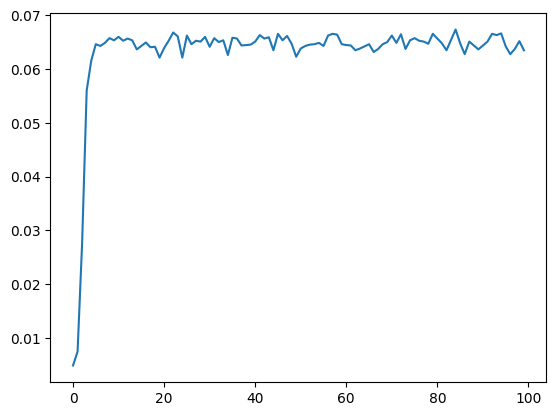

In [16]:
sns.lineplot(val_hr)

/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

<Axes: >

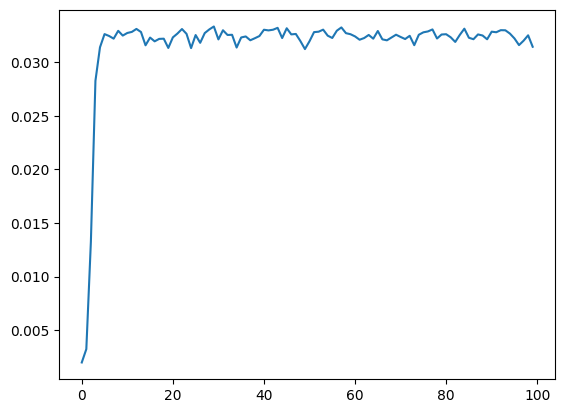

In [17]:
sns.lineplot(val_ndcg)

In [18]:
user_id = 0
items_to_rank = test_dataset.all_items - test_dataset.users_train_data[user_id]
with torch.no_grad():
    preds = bpr.predict(test_dataset[user_id][0], test_dataset[user_id][1])
    print(preds.shape)
    vals, ind = torch.topk(preds, 5)
    print(f"Top K: scores: {vals}, indices:{ind}")
    top_k_item_ids = torch.take(torch.as_tensor(list(items_to_rank)), ind)
    true_pos = test_dataset[user_id][2]
    print(f"top k item ids: {top_k_item_ids}")
    print(true_pos)
    print(set(top_k_item_ids.tolist()).intersection(set(true_pos.tolist())))

torch.Size([1427])
Top K: scores: tensor([0.8391, 0.7675, 0.7079, 0.6848, 0.6810]), indices:tensor([280, 116, 400, 277, 324])
top k item ids: tensor([481, 317, 601, 478, 525])
tensor([188,  97, 169,  70, 107, 176, 183, 248, 229, 238, 217,  74,  46, 261,
         25,  91, 152, 249,  83, 266,   8,  38, 216,  72,  14,  64,  82,  98,
         43, 203, 194, 157, 149,  12,  42, 226, 184, 138, 201, 268, 205,  86,
         81, 267, 189,   6,  76, 161,  18, 240, 264, 193, 146, 113, 127,  51,
         54,   4, 131, 136, 235, 206,  44])
set()


In [19]:
test_df[test_df.user_id == user_id]

,user_id,item_id,rating
405,0,188,3
1178,0,97,4
1786,0,169,5
2177,0,70,3
2391,0,107,5
...,...,...,...
20440,0,131,4
21436,0,136,5
22148,0,235,4
22974,0,206,5


In [20]:
test_df[(test_df.user_id == user_id) & (test_df.item_id.isin(top_k_item_ids.tolist()))]

,user_id,item_id,rating


In [21]:
test_df[(test_df.user_id == 0) & test_df.item_id.isin(top_k_item_ids.tolist())]

,user_id,item_id,rating
